In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="ufl")
import dolfin as dl
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
try:
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif', size=20)
    matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
except:
    pass
import sys, os
sys.path.append(os.environ.get('HIPPYLIB_PATH'))
import hippylib as hp
sys.path.insert(0, '../')
from modeling import *
dl.parameters["form_compiler"]["optimize"]     = True
dl.parameters["form_compiler"]["cpp_optimize"] = True
dl.parameters["form_compiler"]["cpp_optimize_flags"] = "-O3 -ffast-math -march=native"

In [2]:
settings = KelvinVoigtSettings()
settings["n_cells"] =500
settings["FE_order"] = 1
settings["dim"] = 1
np.random.seed(0)
random.seed(0)
print(settings)

{'n_cells': 500, 'dim': 1, 'FE_order': 1, 'direct_solver': True}


In [3]:
cell_problem = KelvinVoigtCellProblem(**settings) #input the dictionary entries as keyword arguments
cell_problem.parameters["verbose"]=True
cell_problem.parameters["nt"] = 5000
cell_problem.parameters["T"] = 1.0
print(cell_problem.parameters)
Vh = cell_problem.FunctionSpace()
Sh = cell_problem.FunctionSpace(type="scalar")
SPh = cell_problem.FunctionSpace(type="scalar_periodic")
print("Degrees of freedom: \nFree vector space Vh: %d \nPeriodic space Ph: %d"%(Vh.dim(), SPh.dim()))

{'verbose': True, 'nt': 5000, 'T': 1.0, 'maximum_iterations': 200, 'relative_tolerance': 1e-10}
Degrees of freedom: 
Free vector space Vh: 501 
Periodic space Ph: 500


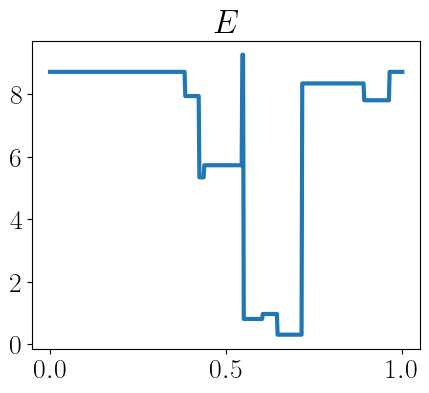

In [4]:
n_points = 10
points = np.random.uniform(low = 0.0, high = 1.0, size = n_points)
points = np.sort(points)
values = np.random.uniform(low = 0.1, high = 10, size = n_points)
E = PC1DMicrostructure(Sh, points, values)
plt.figure(figsize=(5,4))
plot_vec(E, Sh, lw=3, color="C0")
plt.title(r"$E$")
plt.show()

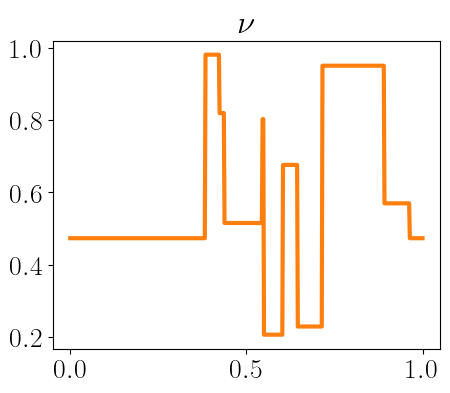

In [5]:
values = np.random.uniform(low = 0.1, high = 1.0, size = n_points)
nu = PC1DMicrostructure(Sh, points, values)
plt.figure(figsize=(5,4))
plot_vec(nu, Sh, lw=3, color="C1")
plt.title(r"$\nu$")
plt.show()

In [6]:
cell_problem.set_microstructure(E, nu)

Assemble required matrices and vectors....
Finished. Took 0.03s


In [16]:
n_interval = 20 #the number of interval that will be subsampled to generate time points
d = int(((settings["dim"]+1)*settings["dim"])/2) #dimension of the symmetric part of strain components
ebar, t_list, value_list = generate_trajectory(n_interval, d, low = -0.2, high = 0.2)
rate = ebar.rate()

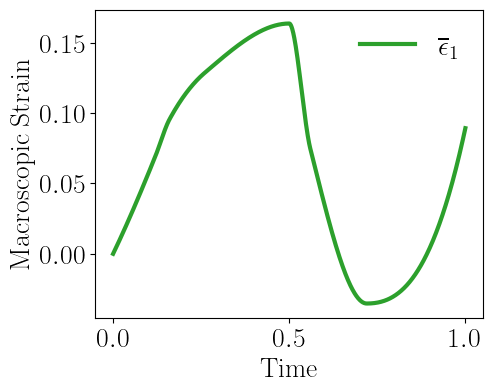

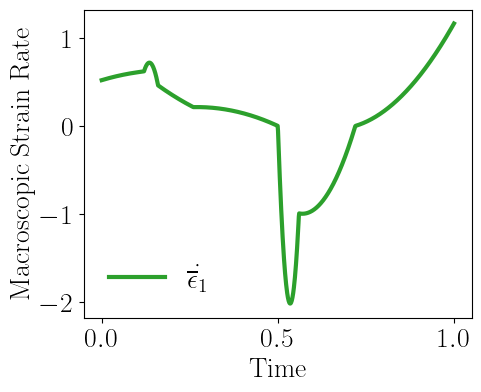

In [17]:
plt.figure(0, figsize=(5,4))
for i in range(d):
    ebar.plot(component = i,label = r"$\overline{\epsilon}_{%d}$"%(i+1), color="C2", lw=3)
plt.legend(frameon=False)
plt.xlabel("Time")
plt.ylabel("Macroscopic Strain")
plt.figure(1, figsize=(5,4))
for i in range(d):
    rate.plot(component = i, label = r"$\dot{\overline{\epsilon}_{%d}}$"%(i+1), color="C2", lw=3)
plt.legend(frameon=False)
plt.xlabel("Time")
plt.ylabel("Macroscopic Strain Rate")
plt.show()

In [18]:
t, stress= cell_problem.solve(ebar, rate)

Solving the cell problem....
Total time: 3.04s
Solve: 2.46s (80.92%)
Stress estimation: 0.22s (7.26%)
Ebar and rate evaluation: 0.33s (10.77%)


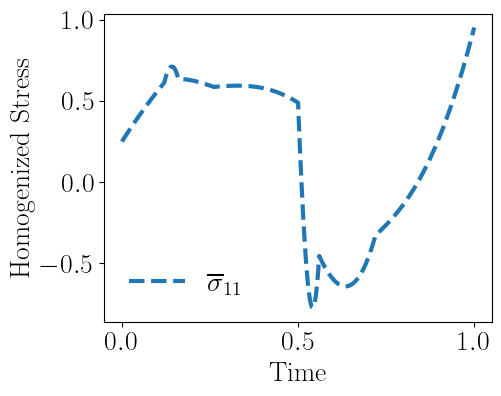

In [19]:
plt.figure(figsize=(5,4))
plt.plot(t, stress[:, 0], "--", label = r"$\overline{\sigma}_{11}$", lw=3)
plt.xlabel("Time")
plt.ylabel("Homogenized Stress")
plt.legend(frameon=False)
plt.show()

In [20]:
t, stress, u_list = cell_problem.solve(ebar, rate, return_displacement = True)

Computing displacement is done via L2 project and it can be slow.
Solving the cell problem....
Total time: 11.85s
Solve: 2.15s (18.11%)
Stress estimation: 0.26s (2.18%)
Ebar and rate evaluation: 0.38s (3.19%)
Solution to displacement mapping: 9.01s (76.05%)


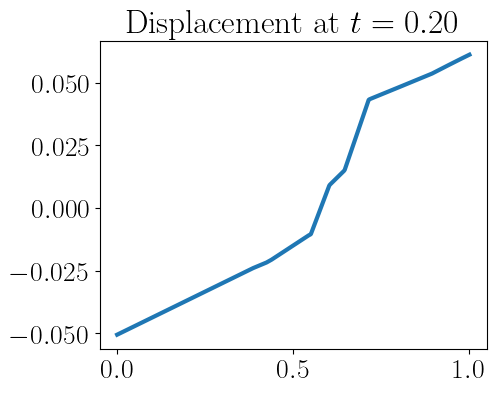

In [21]:
snapshot = 1000
plt.figure(figsize=(5,4))
plot_vec(u_list[snapshot], Sh, lw=3)
plt.title("Displacement at $t = %1.2f$"%(t[snapshot]))
plt.show()

In [22]:
nu_prime, E_prime, kernel = cell_problem.extract_memory_form()

Extracting (nu', E', K(t)) memory form...
Finished memory form extraction. Took 1.67s


In [23]:
memory_form = KelvinVoigtHomogenizedModel(nu_prime, E_prime, kernel)
_, stress_memory_form = memory_form.predict(ebar, rate)

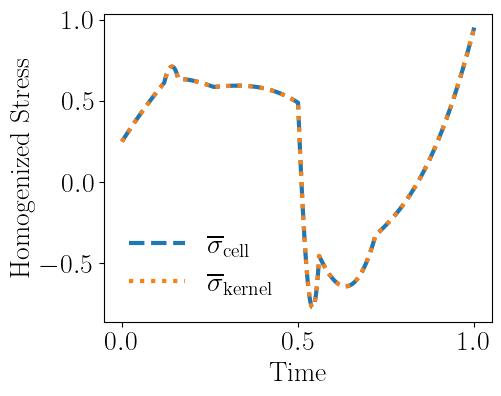

In [25]:
plt.figure(figsize=(5,4))
plt.plot(t, stress[:, 0], "--", label = r"$\overline{\sigma}_{\text{cell}}$", lw=3)
plt.plot(t, stress_memory_form[:, 0], ":", label = r"$\overline{\sigma}_{\text{kernel}}$", lw=3)
plt.xlabel("Time")
plt.ylabel("Homogenized Stress")
plt.legend(frameon=False)
plt.show()